Great topic 👍
I’ll explain **Supervisor Agents and Swarms** in a **clear, layered way**, so you understand **what they are, why they exist, and how they work together** — without code first.

---

# 🧠 BIG PICTURE (WHY THIS EXISTS)

As tasks become complex, **one agent is not enough**.

Example:

> “Analyze logs, find bugs, fix code, write tests, summarize result”

A single agent:

* Gets confused
* Mixes responsibilities
* Is hard to control

👉 Solution: **Multiple agents with roles**

That’s where **Supervisor + Swarm** comes in.

---

# 🔹 WHAT IS A SUPERVISOR AGENT?

### Simple definition:

> A **Supervisor Agent** is a **manager agent** that decides:

* *Who should work*
* *On what*
* *In what order*

Think of it as:
🧑‍💼 **Tech Lead / Project Manager**

It **does NOT do the actual work**.

---

## Supervisor Responsibilities

* Understand user goal
* Break task into sub-tasks
* Assign tasks to specialist agents
* Decide when to stop
* Handle failures

---

## Supervisor DOES NOT

❌ Write code
❌ Analyze deeply
❌ Generate long content

It **coordinates**.

---

# 🔹 WHAT IS A SWARM?

### Simple definition:

> A **Swarm** is a group of **specialized agents** working together.

Think of:
👥 Backend Dev
👥 QA
👥 Security
👥 Docs Writer

Each agent:

* Has a **single responsibility**
* Uses its own tools
* Works independently

---

## Swarm Characteristics

* Decentralized execution
* Specialized skills
* Can run in parallel
* Communicate via shared state

---

# 🔹 SUPERVISOR + SWARM (TOGETHER)

### Mental model:

```
User Request
     ↓
Supervisor Agent
     ↓
-------------------------
|  Agent A  |  Agent B |
| (Code)    | (Review) |
-------------------------
     ↓
Supervisor
     ↓
Final Answer
```

Supervisor:

* Routes work
* Reads results
* Decides next step

---

# 🔹 WHY NOT JUST REACT?

ReAct agent:

* Thinks + acts step by step
* Good for **single-thread reasoning**

But:
❌ Hard to scale
❌ No clear ownership
❌ Poor for parallel work

Supervisor + Swarm:
✅ Scalable
✅ Modular
✅ Production-friendly

---

# 🔹 REAL-WORLD EXAMPLE

### Task:

> “Build a customer support AI”

Supervisor plan:

1. Agent A → classify user intent
2. Agent B → search knowledge base
3. Agent C → analyze sentiment
4. Agent D → draft response

Supervisor decides:

* Escalate to human?
* Ask follow-up?
* End conversation?

---

# 🔹 HOW THIS LOOKS IN LANGGRAPH (CONCEPTUALLY)

### Nodes:

* supervisor
* retrieval_agent
* sentiment_agent
* response_agent

### Edges:

* supervisor → agent
* agent → supervisor

Supervisor is the **router**.

---

# 🔹 CONTROL FLOW STYLE

### Decision-based

```
If intent == billing → BillingAgent
If intent == tech → TechAgent
If angry → EscalationAgent
```

### Or iterative

```
Supervisor → Agent → Supervisor → Agent → END
```

---

# 🔹 WHY THIS MATTERS (INTERVIEW / REAL SYSTEMS)

Big companies use this model because:

* Safer outputs
* Clear audit trail
* Easier debugging
* Independent upgrades

This is how:

* AutoGPT-style systems work
* Devin-like agents are built
* Enterprise copilots scale

---

# 🔹 KEY DIFFERENCE SUMMARY

| Concept    | Role                    |
| ---------- | ----------------------- |
| Supervisor | Orchestrator            |
| Swarm      | Workers                 |
| ReAct      | Single intelligent loop |
| RAG        | Knowledge provider      |
| Memory     | Context storage         |

---

# 🧠 FINAL INTUITION (REMEMBER THIS)

> **Supervisor = Brain**
> **Swarm = Hands**

The brain decides **what to do**,
the hands actually **do it**.

---

If you want next, I can:
1️⃣ Map this to **LangGraph nodes**
2️⃣ Show **supervisor routing logic**
3️⃣ Explain **parallel vs sequential swarms**
4️⃣ Build a **complete example**

Just say the number 👍


In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model

# LLM
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# STATE
class SupportState(TypedDict):
    user_query: str
    intent: str
    sentiment: str
    response: str




E:\EDU_CARE\arg_venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
E:\EDU_CARE\arg_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# SUPERVISOR (ROUTER)
def supervisor(state: SupportState) -> SupportState:
    prompt = f"""
Classify the user query into one intent:
- faq
- technical
- complaint

Query: {state['user_query']}

Reply with only the intent.
"""
    intent = llm.invoke(prompt).content.strip().lower()
    state["intent"] = intent
    return state

# FAQ AGENT
def faq_agent(state: SupportState) -> SupportState:
    prompt = f"""
Answer the FAQ question clearly.

Question: {state['user_query']}
"""
    state["response"] = llm.invoke(prompt).content
    return state

# TECHNICAL AGENT
def tech_agent(state: SupportState) -> SupportState:
    prompt = f"""
Provide technical troubleshooting steps.

Issue: {state['user_query']}
"""
    state["response"] = llm.invoke(prompt).content
    return state

# SENTIMENT AGENT
def sentiment_agent(state: SupportState) -> SupportState:
    prompt = f"""
Detect sentiment: positive, neutral, or angry.

Text: {state['user_query']}
"""
    state["sentiment"] = llm.invoke(prompt).content.strip().lower()

    if state["sentiment"] in {"angry","fustrated"}:
        state["response"] = "Your issue is being escalated to human support."
    else:
        state["response"] = "Thank you for your feedback!"

    return state

# ROUTING LOGIC
def route(state: SupportState) -> Literal["faq", "tech", "sentiment"]:
    if state["intent"] == "faq":
        return "faq"
    if state["intent"] == "technical":
        return "tech"
    return "sentiment"



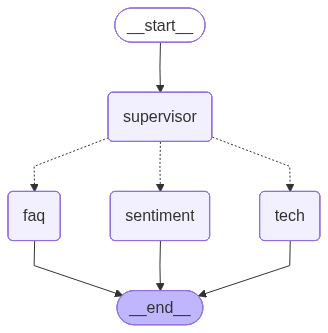

In [3]:
# BUILD GRAPH
graph = StateGraph(SupportState)

graph.add_node("supervisor", supervisor)
graph.add_node("faq", faq_agent)
graph.add_node("tech", tech_agent)
graph.add_node("sentiment", sentiment_agent)

graph.add_edge(START, "supervisor")

graph.add_conditional_edges(
    "supervisor",
    route,
    {
        "faq": "faq",
        "tech": "tech",
        "sentiment": "sentiment"
    }
)

graph.add_edge("faq", END)
graph.add_edge("tech", END)
graph.add_edge("sentiment", END)

app = graph.compile()

# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# RUN
result = app.invoke({
    "user_query": "My internet is not working, help me to fix it."
})

print("\nFINAL RESPONSE:\n")
print(result["response"])


FINAL RESPONSE:

Here are some technical troubleshooting steps to help you resolve the issue with your internet connection:

**Step 1: Basic Checks**

1. **Power cycle your router**: Unplug the power cord from the back of your router, wait for 30 seconds, and then plug it back in. This will reset your router and may resolve any connectivity issues.
2. **Check your cables**: Ensure that all cables, including Ethernet cables and power cords, are securely connected to their respective devices.
3. **Verify your internet service provider (ISP) status**: Check your ISP's website or social media for any outages or maintenance in your area.

**Step 2: Router and Modem Checks**

1. **Check your router's lights**: Ensure that your router's lights are indicating a stable connection. Typically, a solid green light indicates a stable connection, while a flashing or red light may indicate a problem.
2. **Restart your modem**: Unplug the power cord from the back of your modem, wait for 30 seconds, a

C:\Users\royar\AppData\Local\Temp\ipykernel_20544\4165547069.py:55: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  mathematician = create_react_agent(
C:\Users\royar\AppData\Local\Temp\ipykernel_20544\4165547069.py:66: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  sw_engineer = create_react_agent(
C:\Users\royar\AppData\Local\Temp\ipykernel_20544\4165547069.py:77: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  researcher = create_react_agent(


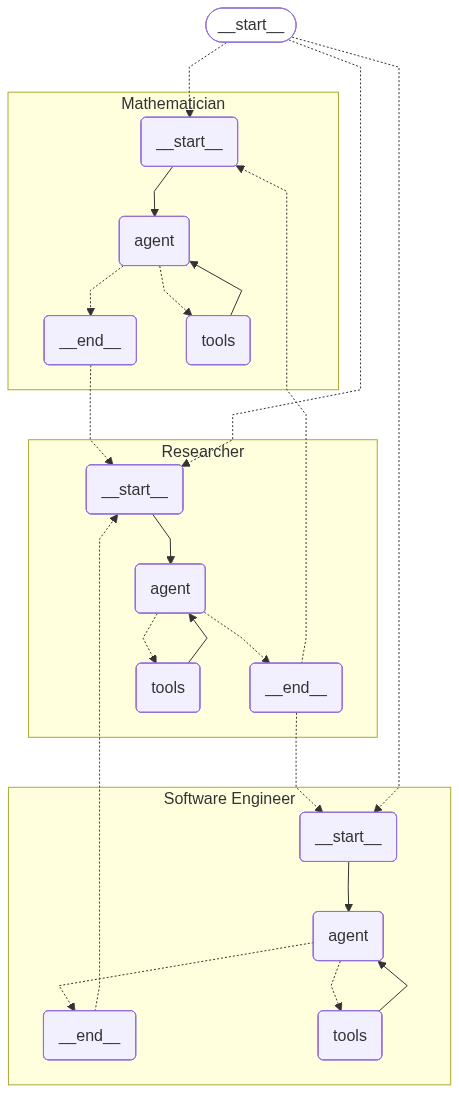

I can't fulfill your request.


In [9]:
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_handoff_tool, create_swarm

# ================= MODEL =================
model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# ================= TOOLS =================
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers"""
    return a - b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """Divide two numbers"""
    return a / b


# ================= HANDOFF TOOLS  =================
to_researcher = create_handoff_tool(
    agent_name="Researcher",
    description="Transfer task to Researcher"
)

to_math = create_handoff_tool(
    agent_name="Mathematician",
    description="Transfer task to Mathematician"
)

to_engineer = create_handoff_tool(
    agent_name="Software Engineer",
    description="Transfer task to Software Engineer"
)


# ================= AGENTS =================

mathematician = create_react_agent(
    model=model,
    tools=[add, subtract, multiply, divide, to_researcher],
    prompt="""
You are a mathematician.
Do math.
If task is NOT math → transfer to Researcher.
""",
    name="Mathematician",
)

sw_engineer = create_react_agent(
    model=model,
    tools=[to_researcher],
    prompt="""
You are a senior full-stack AI software engineer.
Write minimal clean and working code.
If routing needed → transfer to Researcher.
""",
    name="Software Engineer",
)

researcher = create_react_agent(
    model=model,
    tools=[to_math, to_engineer],
    prompt="""
You are a team lead router.
Decide which agent should handle task.

Math → Mathematician
Coding → Software Engineer

Do NOT transfer repeatedly.
""",
    name="Researcher",
)

# ================= SWARM =================
checkpointer = InMemorySaver()

workflow = create_swarm(
    agents=[researcher, mathematician, sw_engineer],
    default_active_agent="Researcher",
)

app = workflow.compile(checkpointer=checkpointer)

# ================= VISUALIZE =================
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# ================= RUN =================
config = {"configurable": {"thread_id": "1"}}

result = app.invoke(
    {"messages": [{"role": "user", "content": "Create an android Calculator app in python and a good UI,which i can install and use in my android phone. try to use minimum token."}]},
    config,
)

print(result["messages"][-1].content)